### Class 38 workout
Date: 15 April 2026 
(by Vikram Khaire)

Class 37 was theory

Topic: Intro. to ML (Neural networks)

In [1]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt
import copy

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, log_loss

In [2]:
# added to ignore convergence warnings
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [3]:
# 1. LOAD DATA
# ============================================================
digits = load_digits()

X = digits.data          # shape: (n_samples, 64)
y = digits.target        # labels 0–9

print("Data shape:", X.shape)
print("Number of features per sample:", X.shape[1])
print("Number of classes:", len(np.unique(y)))


Data shape: (1797, 64)
Number of features per sample: 64
Number of classes: 10


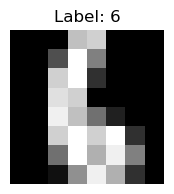

In [4]:
# Show one sample
plt.figure(figsize=(2,2))
plt.imshow(X[6].reshape(8,8), cmap='gray')
plt.title(f"Label: {y[6]}")
plt.axis('off')
plt.show()

In [5]:
# Values
X[6]

array([ 0.,  0.,  0., 12., 13.,  0.,  0.,  0.,  0.,  0.,  5., 16.,  8.,
        0.,  0.,  0.,  0.,  0., 13., 16.,  3.,  0.,  0.,  0.,  0.,  0.,
       14., 13.,  0.,  0.,  0.,  0.,  0.,  0., 15., 12.,  7.,  2.,  0.,
        0.,  0.,  0., 13., 16., 13., 16.,  3.,  0.,  0.,  0.,  7., 16.,
       11., 15.,  8.,  0.,  0.,  0.,  1.,  9., 15., 11.,  3.,  0.])

In [6]:
# 2. NORMALIZATION
# ============================================================
print("\nBefore normalization:")
print("Min:", X.min(), "Max:", X.max())

X = X / 16.0   # pixel values go from 0–16 → scale to 0–1

print("\nAfter normalization:")
print("Min:", X.min(), "Max:", X.max())

# ------------------------------------------------------------


Before normalization:
Min: 0.0 Max: 16.0

After normalization:
Min: 0.0 Max: 1.0


In [7]:
# 3. TRAIN-TEST SPLIT
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTrain size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (1437, 64)
Test size: (360, 64)


# 4. DEFINE NEURAL NETWORK - old style
# ============================================================
model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='sgd',              # simple gradient descent
    learning_rate_init=0.01,   # YOUR learning rate
    learning_rate='constant',  # keep it fixed
    max_iter=1,
    warm_start=True,
    random_state=42
)

In [8]:
# 4. DEFINE NEURAL NETWORK
# ============================================================
model = MLPClassifier(
    hidden_layer_sizes=(64, 32),  # architecture
    activation='relu',            # activation function
    solver='adam',                # optimizer
    max_iter=1,                   # IMPORTANT: we train manually
    warm_start=True,              # keep training
    random_state=42
)

print("\nModel architecture:")
print("Input layer: 64 neurons (pixels)")
print("Hidden layers: 64 → 32")
print("Output layer: 10 neurons (digits 0–9)")


Model architecture:
Input layer: 64 neurons (pixels)
Hidden layers: 64 → 32
Output layer: 10 neurons (digits 0–9)


In [9]:
# 5. TRAINING LOOP (For showing how it learns)
# ============================================================
train_loss = []
test_loss = []

epochs = 200

for epoch in range(epochs):
    model.fit(X_train, y_train)

    # Predict probabilities
    y_train_prob = model.predict_proba(X_train)
    y_test_prob = model.predict_proba(X_test)

    # Compute log loss
    tr_loss = log_loss(y_train, y_train_prob)
    te_loss = log_loss(y_test, y_test_prob)

    train_loss.append(tr_loss)
    test_loss.append(te_loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Train Loss={tr_loss:.4f}, Test Loss={te_loss:.4f}")


Epoch 0: Train Loss=2.2467, Test Loss=2.2636
Epoch 10: Train Loss=0.7220, Test Loss=0.7242
Epoch 20: Train Loss=0.2389, Test Loss=0.2512
Epoch 30: Train Loss=0.1292, Test Loss=0.1586
Epoch 40: Train Loss=0.0826, Test Loss=0.1273
Epoch 50: Train Loss=0.0562, Test Loss=0.1147
Epoch 60: Train Loss=0.0397, Test Loss=0.1098
Epoch 70: Train Loss=0.0287, Test Loss=0.1095
Epoch 80: Train Loss=0.0209, Test Loss=0.1118
Epoch 90: Train Loss=0.0153, Test Loss=0.1142
Epoch 100: Train Loss=0.0113, Test Loss=0.1180
Epoch 110: Train Loss=0.0081, Test Loss=0.1218
Epoch 120: Train Loss=0.0061, Test Loss=0.1281
Epoch 130: Train Loss=0.0047, Test Loss=0.1349
Epoch 140: Train Loss=0.0035, Test Loss=0.1436
Epoch 150: Train Loss=0.0027, Test Loss=0.1517
Epoch 160: Train Loss=0.0021, Test Loss=0.1573
Epoch 170: Train Loss=0.0015, Test Loss=0.1639
Epoch 180: Train Loss=0.0011, Test Loss=0.1699
Epoch 190: Train Loss=0.0008, Test Loss=0.1722


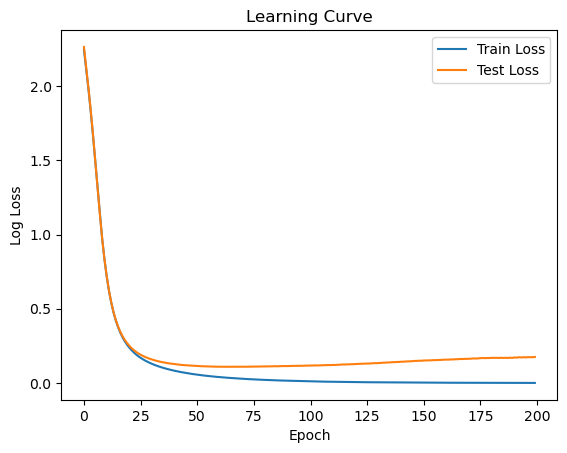

In [10]:
# 6. PLOT LEARNING CURVE
# ============================================================
plt.figure()
plt.plot(train_loss, label="Train Loss")
plt.plot(test_loss, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Log Loss")
plt.title("Learning Curve")
plt.legend()
plt.show()


Final Accuracy: 0.9694444444444444


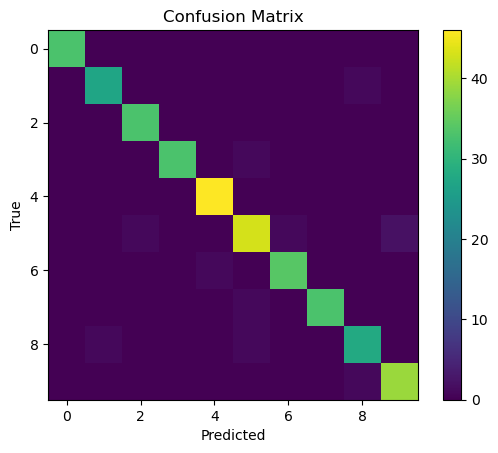

In [11]:
# 7. FINAL EVALUATION
# ============================================================
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("\nFinal Accuracy:", accuracy)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.show()


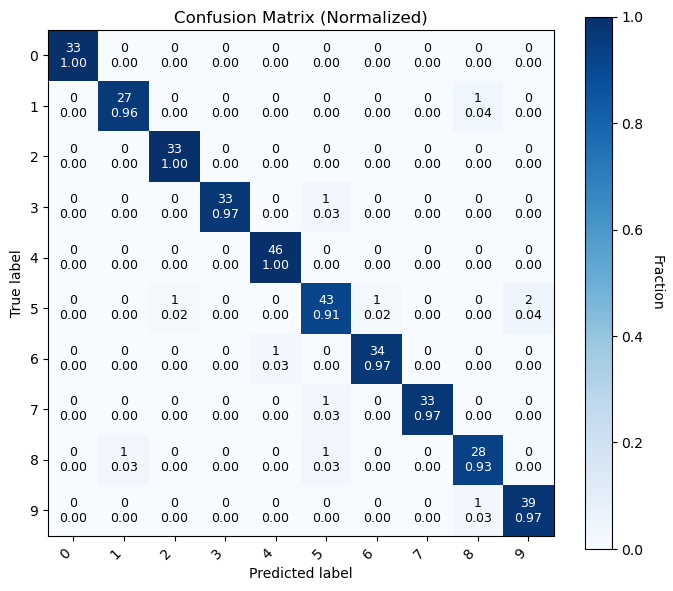

In [12]:
# just a better way of showing this - with ChatGPT help:

cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

classes = np.arange(10)

fig, ax = plt.subplots(figsize=(7,6))

# Use lighter colormap
im = ax.imshow(cm_norm, cmap='Blues')

# Colorbar
cbar = ax.figure.colorbar(im, ax=ax)
cbar.ax.set_ylabel("Fraction", rotation=-90, va="bottom")

# Axis labels
ax.set(
    xticks=classes,
    yticks=classes,
    xticklabels=classes,
    yticklabels=classes,
    xlabel="Predicted label",
    ylabel="True label",
    title="Confusion Matrix (Normalized)"
)

plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Dynamic text color
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        frac = cm_norm[i, j]
        count = cm[i, j]

        # Choose text color based on background
        color = "white" if frac > 0.5 else "black"

        ax.text(j, i,
                f"{count}\n{frac:.2f}",
                ha="center", va="center",
                color=color,
                fontsize=9)

plt.tight_layout()
plt.show()

[21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40]


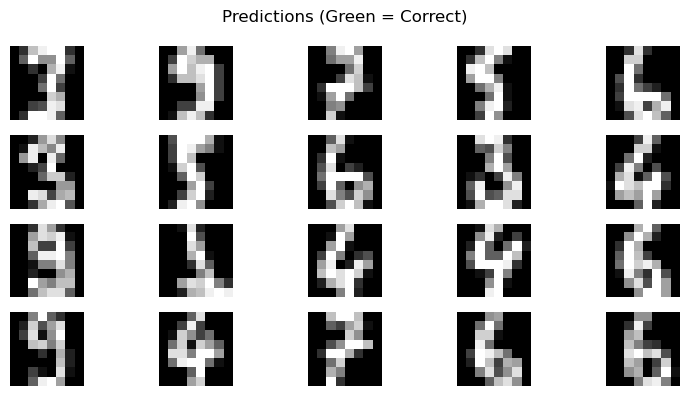

In [13]:
# 8. VISUALIZE PREDICTIONS
# ============================================================
plt.figure(figsize=(8,4))

shapes = np.arange(21, 41)
print(shapes)
for i in shapes:
    plt.subplot(4,5,i+1-shapes[0])
    plt.imshow(X_test[i].reshape(8,8), cmap='gray')

    pred = y_pred[i]
    true = y_test[i]

    color = "green" if pred == true else "red"
    #plt.title(f"P:{pred} T:{true}", color=color, fontsize=10)
    plt.axis('off')

plt.suptitle("Predictions (Green = Correct)")
plt.tight_layout()
plt.show()

[21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40]


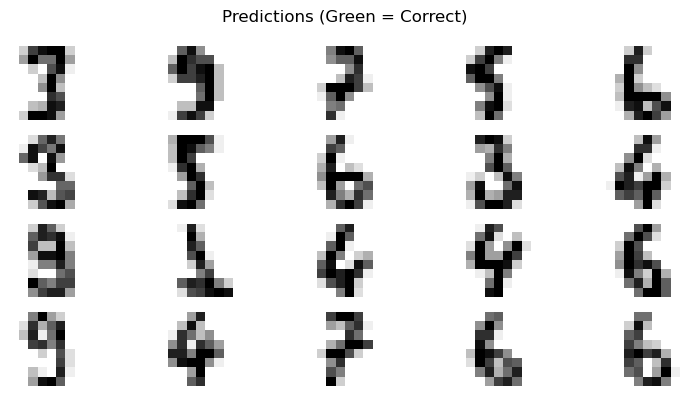

In [14]:
# 8. VISUALIZE PREDICTIONS
# ============================================================
plt.figure(figsize=(8,4))

shapes = np.arange(21, 41)
print(shapes)
for i in shapes:
    plt.subplot(4,5,i+1-shapes[0])
    plt.imshow(X_test[i].reshape(8,8), cmap='gray_r')

    pred = y_pred[i]
    true = y_test[i]

    color = "green" if pred == true else "red"
    #plt.title(f"P:{pred} T:{true}", color=color, fontsize=10)
    plt.axis('off')

plt.suptitle("Predictions (Green = Correct)")
plt.tight_layout()
plt.show()

[21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40]


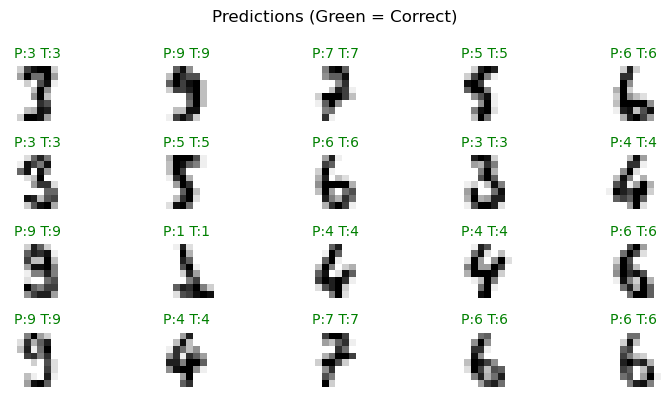

In [15]:
# 8. VISUALIZE PREDICTIONS
# ============================================================
plt.figure(figsize=(8,4))

shapes = np.arange(21, 41)
print(shapes)
for i in shapes:
    plt.subplot(4,5,i+1-shapes[0])
    plt.imshow(X_test[i].reshape(8,8), cmap='gray_r')

    pred = y_pred[i]
    true = y_test[i]

    color = "green" if pred == true else "red"
    plt.title(f"P:{pred} T:{true}", color=color, fontsize=10)
    plt.axis('off')

plt.suptitle("Predictions (Green = Correct)")
plt.tight_layout()
plt.show()

In [16]:
# overtraining issue

In [17]:
# 4. DEFINE NEURAL NETWORK
# ============================================================
model = MLPClassifier(
    hidden_layer_sizes=(64, 32),  # architecture
    activation='relu',            # activation function
    solver='adam',                # optimizer
    max_iter=1,                   # IMPORTANT: we train manually
    warm_start=True,              # keep training
    random_state=42
)

print("\nModel architecture:")
print("Input layer: 64 neurons (pixels)")
print("Hidden layers: 64 → 32")
print("Output layer: 10 neurons (digits 0–9)")


Model architecture:
Input layer: 64 neurons (pixels)
Hidden layers: 64 → 32
Output layer: 10 neurons (digits 0–9)


In [18]:
# 5. TRAINING LOOP (with best model tracking)
# ============================================================
train_loss = []
test_loss = []

epochs = 400

best_loss = np.inf
best_epoch = -1
best_model = None

for epoch in range(epochs):
    model.fit(X_train, y_train)

    # Predict probabilities
    y_train_prob = model.predict_proba(X_train)
    y_test_prob = model.predict_proba(X_test)

    # Compute log loss
    tr_loss = log_loss(y_train, y_train_prob)
    te_loss = log_loss(y_test, y_test_prob)

    train_loss.append(tr_loss)
    test_loss.append(te_loss)

    # ---- Track best model ----
    if te_loss < best_loss:
        best_loss = te_loss
        best_epoch = epoch
        best_model = copy.deepcopy(model)

    if epoch % 20 == 0:
        print(f"Epoch {epoch}: Train Loss={tr_loss:.4f}, Test Loss={te_loss:.4f}")

# ============================================================
# After training
# ============================================================
print("\nBest epoch:", best_epoch)
print("Best test loss:", best_loss)

# Use best model for predictions
model = best_model

Epoch 0: Train Loss=2.2467, Test Loss=2.2636
Epoch 20: Train Loss=0.2389, Test Loss=0.2512
Epoch 40: Train Loss=0.0826, Test Loss=0.1273
Epoch 60: Train Loss=0.0397, Test Loss=0.1098
Epoch 80: Train Loss=0.0209, Test Loss=0.1118
Epoch 100: Train Loss=0.0113, Test Loss=0.1180
Epoch 120: Train Loss=0.0061, Test Loss=0.1281
Epoch 140: Train Loss=0.0035, Test Loss=0.1436
Epoch 160: Train Loss=0.0021, Test Loss=0.1573
Epoch 180: Train Loss=0.0011, Test Loss=0.1699
Epoch 200: Train Loss=0.0007, Test Loss=0.1750
Epoch 220: Train Loss=0.0007, Test Loss=0.1773
Epoch 240: Train Loss=0.0009, Test Loss=0.1787
Epoch 260: Train Loss=0.0009, Test Loss=0.1741
Epoch 280: Train Loss=0.0010, Test Loss=0.1835
Epoch 300: Train Loss=0.0010, Test Loss=0.1973
Epoch 320: Train Loss=0.0012, Test Loss=0.2000
Epoch 340: Train Loss=0.0010, Test Loss=0.2078
Epoch 360: Train Loss=0.0004, Test Loss=0.2024
Epoch 380: Train Loss=0.0002, Test Loss=0.1959

Best epoch: 67
Best test loss: 0.10894450791734811



Final Accuracy: 0.9694444444444444


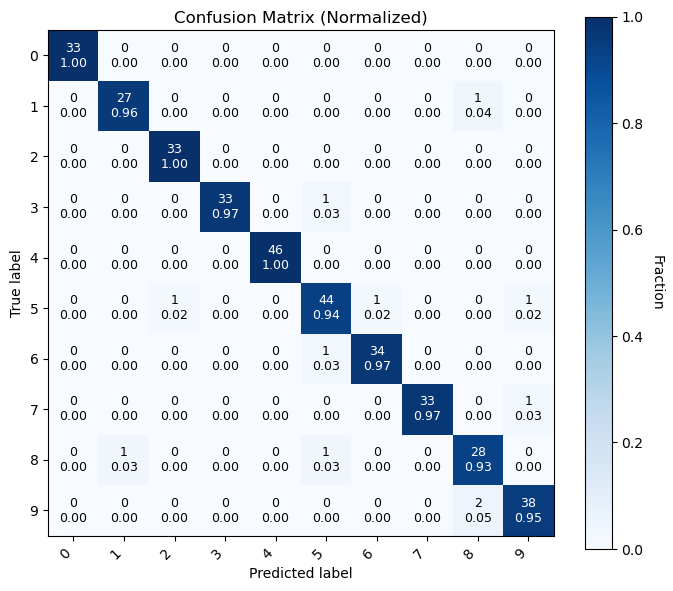

In [19]:
# just a better way of showing this - with ChatGPT help:

# ============================================================
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("\nFinal Accuracy:", accuracy)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

classes = np.arange(10)

fig, ax = plt.subplots(figsize=(7,6))

# Use lighter colormap
im = ax.imshow(cm_norm, cmap='Blues')

# Colorbar
cbar = ax.figure.colorbar(im, ax=ax)
cbar.ax.set_ylabel("Fraction", rotation=-90, va="bottom")

# Axis labels
ax.set(
    xticks=classes,
    yticks=classes,
    xticklabels=classes,
    yticklabels=classes,
    xlabel="Predicted label",
    ylabel="True label",
    title="Confusion Matrix (Normalized)"
)

plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Dynamic text color
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        frac = cm_norm[i, j]
        count = cm[i, j]

        # Choose text color based on background
        color = "white" if frac > 0.5 else "black"

        ax.text(j, i,
                f"{count}\n{frac:.2f}",
                ha="center", va="center",
                color=color,
                fontsize=9)

plt.tight_layout()
plt.show()